#Spider ML Bonus Task

##Importing necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

device = torch.device("cuda") #Device set to GPU

##Loading dataset and splitting into Train/Validation/Test



In [2]:
full_dataset = datasets.FashionMNIST(
    root="./data", #In data file
    train=True,
    download=True, #Makes it faster
    transform=transforms.ToTensor())

train_size = int(0.8 * len(full_dataset)) #80% of Train is for training while 20% is for validation dataset
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset,[train_size, val_size],) #Randomise

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transforms.ToTensor())

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 167kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.16MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.3MB/s]


In [3]:
encoder = nn.Sequential(

    nn.Linear(784, 256),
    nn.ReLU(),

    nn.Linear(256, 128),
    nn.ReLU(),

    nn.Linear(128, 64)).to(device)

decoder = nn.Sequential(

    nn.Linear(64, 128),
    nn.ReLU(),

    nn.Linear(128, 256),
    nn.ReLU(),

    nn.Linear(256, 784),

    nn.Sigmoid()).to(device)

##Setting Loss criteria and Optimizer


In [4]:
criterion = nn.MSELoss() #picture vs picture
optimizer = optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=0.001)

In [5]:
epochs = 20
train_losses = []
val_losses = []

for epoch in range(epochs):
    encoder.train()
    decoder.train()

    running_train_loss = 0

    for images, _ in train_loader:
        images = images.to(device)
        images = images.view(-1, 784)
        optimizer.zero_grad()
        latent = encoder(images)
        reconstructed = decoder(latent)
        loss = criterion(reconstructed,images)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    encoder.eval()
    decoder.eval()
    running_val_loss = 0

    with torch.no_grad():
        for images, _ in val_loader:
            images = images.to(device)
            images = images.view(-1, 784)
            latent = encoder(images)
            reconstructed = decoder(latent)
            loss = criterion(reconstructed,images)
            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Training Loss: {train_loss:.4f} "
        f"Validation Loss: {val_loss:.4f}"
    )

Epoch [1/20] Training Loss: 0.0416 Validation Loss: 0.0237
Epoch [2/20] Training Loss: 0.0215 Validation Loss: 0.0195
Epoch [3/20] Training Loss: 0.0186 Validation Loss: 0.0179
Epoch [4/20] Training Loss: 0.0172 Validation Loss: 0.0166
Epoch [5/20] Training Loss: 0.0161 Validation Loss: 0.0159
Epoch [6/20] Training Loss: 0.0153 Validation Loss: 0.0149
Epoch [7/20] Training Loss: 0.0146 Validation Loss: 0.0142
Epoch [8/20] Training Loss: 0.0139 Validation Loss: 0.0137
Epoch [9/20] Training Loss: 0.0133 Validation Loss: 0.0132
Epoch [10/20] Training Loss: 0.0128 Validation Loss: 0.0127
Epoch [11/20] Training Loss: 0.0124 Validation Loss: 0.0123
Epoch [12/20] Training Loss: 0.0120 Validation Loss: 0.0119
Epoch [13/20] Training Loss: 0.0117 Validation Loss: 0.0116
Epoch [14/20] Training Loss: 0.0113 Validation Loss: 0.0113
Epoch [15/20] Training Loss: 0.0110 Validation Loss: 0.0111
Epoch [16/20] Training Loss: 0.0108 Validation Loss: 0.0108
Epoch [17/20] Training Loss: 0.0106 Validation Lo

##Plotting Figures for Accuracy and Loss vs Epoch

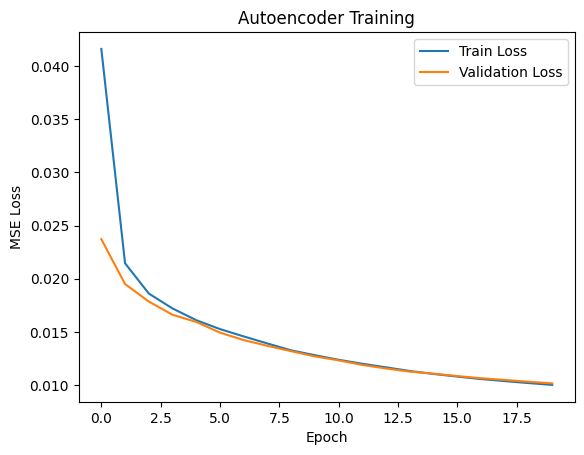

In [6]:
plt.figure()
plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training")
plt.legend()
plt.show()

##Showing original and reconstructed images

In [7]:
encoder.eval()
decoder.eval()

images, _ = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    flat_images = images.view(-1,784)
    latent = encoder(flat_images)
    reconstructed = decoder(latent)

images = images.cpu()
reconstructed = reconstructed.cpu()

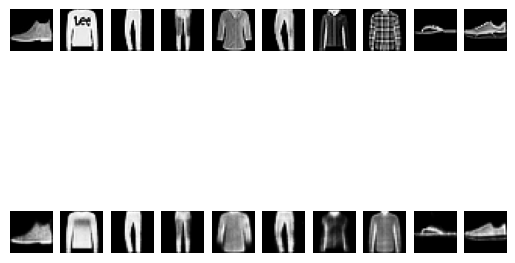

In [8]:
fig, axes = plt.subplots(2,10)

for i in range(10):
    axes[0,i].imshow(images[i].squeeze(),cmap="gray")
    axes[0,i].axis("off")
    axes[1,i].imshow(reconstructed[i].view(28,28),cmap="gray")
    axes[1,i].axis("off")

plt.show()

In [9]:
import os
from PIL import Image
import shutil
from google.colab import files

os.makedirs("zip_data", exist_ok=True)

for i in range(10):

    orig = images[i].squeeze().detach().cpu().numpy()
    orig = (orig * 255).astype(np.uint8)

    orig_img = Image.fromarray(orig)
    orig_img.save(f"zip_data/original({i}).png")

    rec = reconstructed[i].view(28,28).detach().cpu().numpy()
    rec = (rec * 255).astype(np.uint8)

    rec_img = Image.fromarray(rec)
    rec_img.save(f"zip_data/reconstructed({i}).png")

shutil.make_archive("autoencoder_results", "zip", "zip_data")
files.download("autoencoder_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>